Вариант №3

1. Опишите теоретическую модель k-средних.
2. Напишите следующий код: сгенерируйте данные в виде набора точек по нескольким классам; выполните классификацию; оцените точность, визуализируйте результат.
3. Опишите метрику для проверки качества алгоритмов регрессии.

### Задание 1. Опишите теоретическую модель k-средних

Цель: минимизировать внутрикластерное расстояние. Группируем похожие точки данных. Ориентируемся на центроид.

Изначально инициализируем центроиды (например, рандомно). Потом относим точку данных к ближайшему центроиду. Обновляем центроид и повторяем итерации.

Оптимальное K можно найти с помощью различных методов, например, метод локтя или метод силуэта.

1. **Метод локтя**  
Перебираем различные K, обучаем модель и считаем сумму квадратов расстояния от каждой точки до ее кластера. И когда при увеличении K эта метрика перестанет быстро уменьшаться, то такое K станет оптимальным.

2. **Метод силуэта**  
Позволяет оценить "качество" кластеризации. Мы можем посчитать силуэт:  
$ s(i) = \frac{b(i) - a(i)}{max[a(i), b(i)]} $, где  
$a(i)$ - среднее расстояние точки до других точек внутри одного кластера  
$b(i)$ - считаем среднее расстояние до точек других кластеров и берем минимум

### Задание 2. Классификация данных

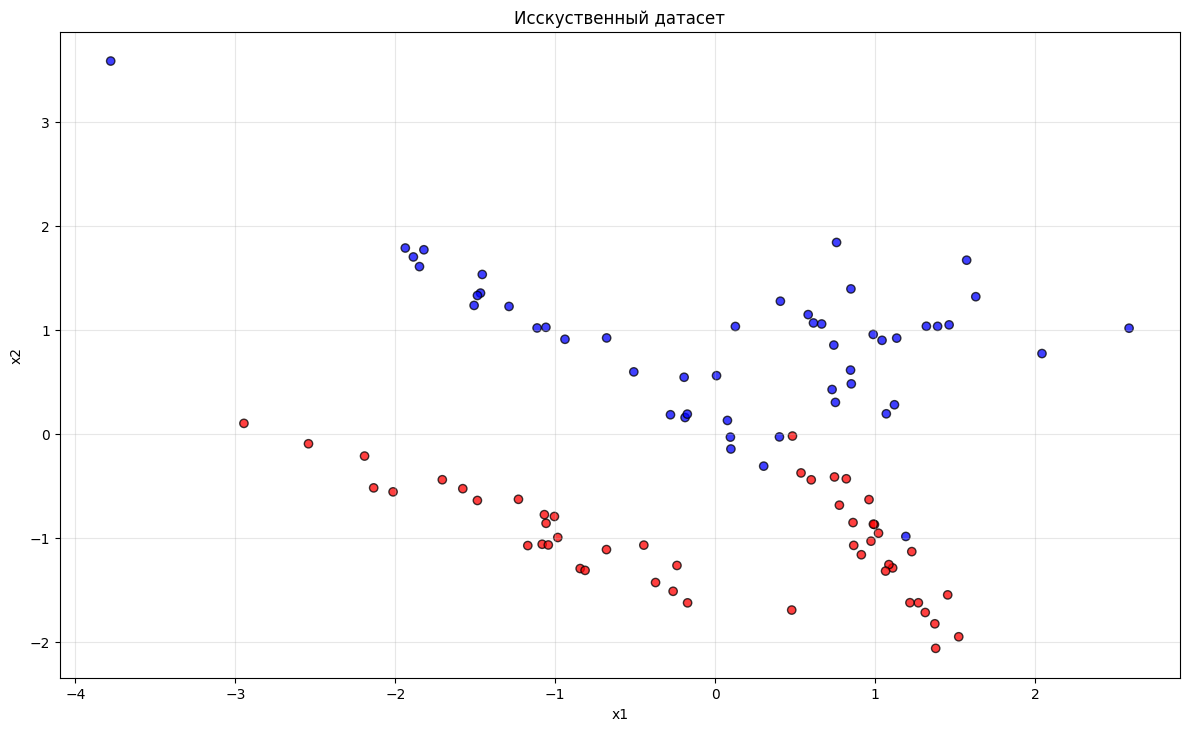

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn import datasets
from matplotlib.colors import ListedColormap

classes = datasets.make_classification(
    n_samples=100, n_features=2, n_informative=2,
    n_redundant=0, n_classes=2, random_state=83
)

colors = ListedColormap(['red', 'blue'])

X = classes[0]
y = classes[1]

plt.figure(figsize=(12, 12/1.618))

plt.title("Исскуственный датасет")
plt.xlabel("x1")
plt.ylabel("x2")

plt.scatter(X[:, 0], X[:, 1], c=y, cmap=colors, alpha=0.75, edgecolor="k")

plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [4]:

np.random.seed(83)
shuffle_index = np.random.permutation(classes[0].shape[0])
X_shuffled, y_shuffled = classes[0][shuffle_index], classes[1][shuffle_index]

train_proportion = 0.7
train_test_cut = int(len(classes[0]) * train_proportion)

X_train, X_test, y_train, y_test = \
    X_shuffled[:train_test_cut], \
    X_shuffled[train_test_cut:], \
    y_shuffled[:train_test_cut], \
    y_shuffled[train_test_cut:]

In [6]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(random_state=83)

model.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,83
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


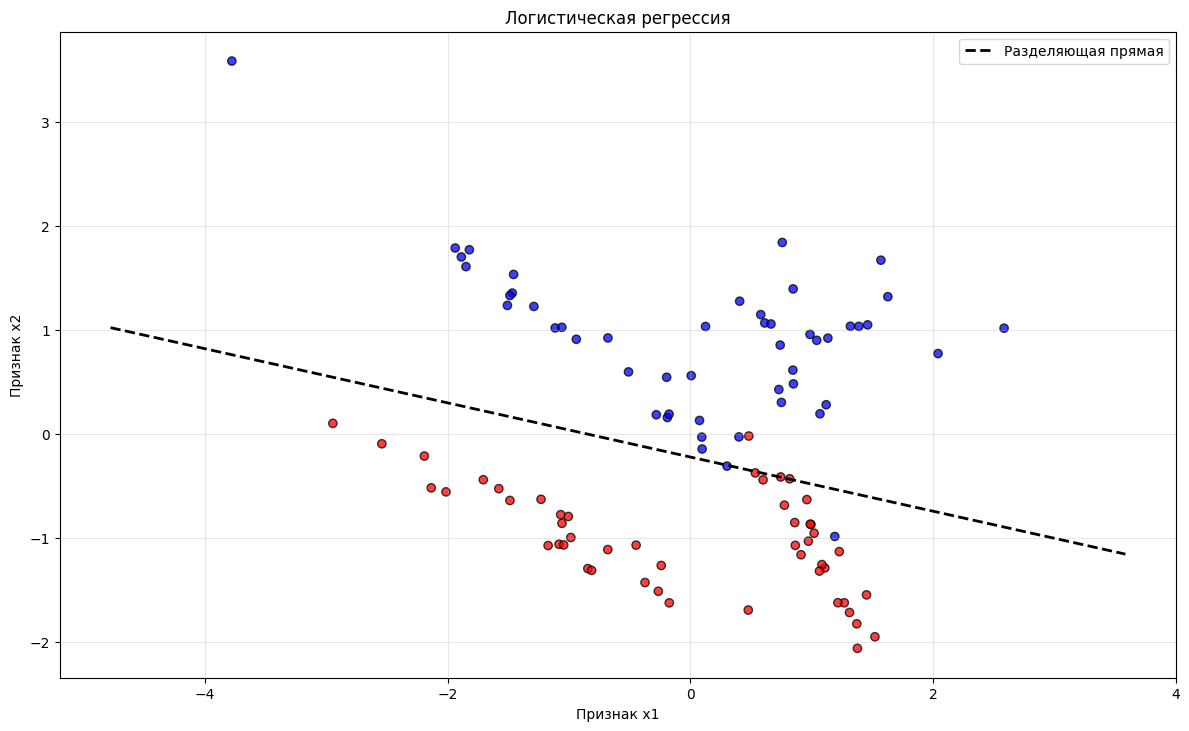

In [17]:
plt.figure(figsize=(12, 12/1.618))
plt.scatter(X[:, 0], X[:, 1], c=y, cmap=colors, edgecolors="k", alpha=0.75)

w = model.coef_[0]
b = model.intercept_[0]

x1_min, x1_max = X[:, 0].min() - 1, X[:, 0].max() + 1
x1_grid = np.linspace(x1_min, x1_max, 100)

x2_grid = -(w[0] * x1_grid + b) / w[1]
plt.plot(x1_grid, x2_grid, 'k--', linewidth=2, label='Разделяющая прямая')

plt.title("Логистическая регрессия")
plt.xlabel("Признак x1")
plt.ylabel("Признак x2")

plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [18]:
train_acc = model.score(X_train, y_train)
test_acc = model.score(X_test, y_test)
print(f"Accuracy на тренировочной: {100*train_acc:.2f}%")
print(f"Accuracy на тестовой:  {100*test_acc:.2f}%")

Accuracy на тренировочной: 94.29%
Accuracy на тестовой:  96.67%


### Задание 3. Опишите метрику для проверки качества алгоритмов регрессии.

- MSE (Mean Square Error)
$$ MSE = \frac{1}{n} \sum_{i=1}^n (y_i - y_i^p)^2$$
- RMSE (Root Mean Square Error)
- MAE (Mean Absolute Error)
- R2 (R-squared)
$$ R^2 = 1 - \frac{\sum_{i=1}^n (y_i - y_i^p)^2}{\sum_{i=1}^n (y_i - y_i^m)^2} $$